In [1]:
import pandas as pd                    # data manipulation and dataframes
import numpy as np                     # numerical operations
import matplotlib.pyplot as plt        # base plotting library
import seaborn as sns                  # statistical visualisations
from statsmodels.stats.outliers_influence import variance_inflation_factor  # VIF for multicollinearity
from sklearn.feature_selection import mutual_info_classif                   # non-linear feature relevance
from scipy.stats import chi2_contingency, mannwhitneyu                      # statistical hypothesis tests

# Telco Customer Churn: EDA and Preprocessing

Predict which customers will leave before they do. The company has ~7,000 customers and wants to identify churn risk early enough to act on it.

This notebook tries to answer two things: which features carry real signal about churn and which ones can be dropped safely. The output is `teleco_model_ready.csv`, a clean unencoded dataset with confirmed drops applied. Encoding happens in the modelling pipeline.

Dataset: IBM Telco Customer Churn. Target: `Churn` (Yes/No). 20 features across demographics, account info and subscribed services.

In [2]:
try:
    teleco_data = pd.read_csv('Teleco_Customer_Churn.csv')
except FileNotFoundError:
    print('File not found — check the path')

---
## 1. Data cleaning

Three things need fixing before the data is usable:
- `TotalCharges` is stored as string instead of a number
- 11 rows have missing values (fixable, not random)
- `customerID` is a leakage risk and needs to go

### 1.1 Initial overview

First pass on shape, dtypes and null counts. Wrong dtypes break downstream transformations: a numeric column stored as `object` won't be scaled or used in distance calculations. Nulls need a strategy before any analysis runs.

In [3]:
print(f'Shape: {teleco_data.shape}')
print(f'\nDtypes:\n{teleco_data.dtypes}')
print(f'\nNull counts:\n{teleco_data.isnull().sum()}')

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Null counts:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Paper

### 1.2 TotalCharges: convert to numeric

`TotalCharges` came in as `object`. Some rows have a whitespace `" "` instead of a number, which stopped pandas from inferring the right dtype on read.

`pd.to_numeric(..., errors='coerce')` fixes it: valid entries convert, invalid entries become `NaN`. Any remaining `NaN` values need a fill strategy before the feature can be used.

In [4]:
teleco_data['TotalCharges'] = pd.to_numeric(teleco_data['TotalCharges'], errors='coerce')
print(f'Nulls in TotalCharges after conversion: {teleco_data["TotalCharges"].isnull().sum()}')

Nulls in TotalCharges after conversion: 11


In [5]:
# Inspect the 11 null rows
teleco_data[teleco_data['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


All 11 rows have `tenure = 0`: new customers who haven't been billed yet. Nothing is actually missing, just nothing to report yet.

Fill with 0. Dropping them wastes real customers and imputing with the mean would be wrong because we already know the right value.

In [6]:
# Fixed: avoid pandas FutureWarning from inplace on chained assignment
teleco_data['TotalCharges'] = teleco_data['TotalCharges'].fillna(0)

### 1.3 Drop customerID

`customerID` is unique per row with no pattern to learn from. Leave it in and the model memorises IDs instead of finding real signals — that's data leakage: perfect training score, useless on new data.

In [7]:
teleco_data = teleco_data.drop('customerID', axis=1)
print(f'Shape after dropping customerID: {teleco_data.shape}')

Shape after dropping customerID: (7043, 20)


In [8]:
# Snapshot of clean data — EDA runs on teleco_data (raw strings), preprocessing starts from here
teleco_preprocessed = teleco_data.copy()
teleco_data.to_csv('teleco_clean.csv', index=False)
print(f'Clean dataset saved → teleco_clean.csv  |  shape: {teleco_preprocessed.shape}')

Clean dataset saved → teleco_clean.csv  |  shape: (7043, 20)


---
## 2. Feature analysis (pre-encoding)

All analysis here runs on raw, unencoded data. Encoding before EDA would distort categorical distributions into arbitrary numeric ranges and make the charts harder to read. The aim is to understand what each feature looks like and how it relates to churn, then use those findings to drive the encoding and drop decisions.

Two approaches: statistical tests to check whether a feature's relationship with churn is real, and distribution plots to see the direction and shape of that relationship. Numerical and categorical features need different methods so they are handled separately.

### 2.1 Target variable: churn balance

How many churners do we have? A dataset that's 99% one class is a trap: a model that always predicts "no churn" scores 99% accuracy while catching zero churners.

At ~27% churn this is moderate imbalance. Use F1 and AUC-ROC when evaluating, not raw accuracy.

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


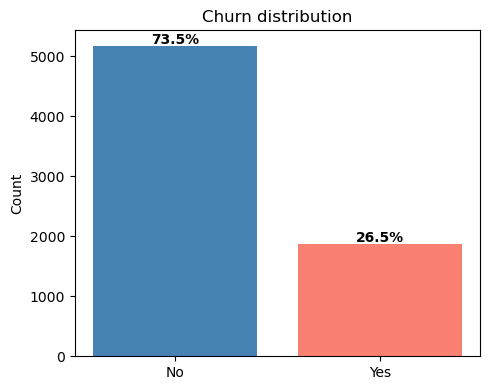

In [9]:
churn_counts = teleco_data['Churn'].value_counts()
churn_pct = teleco_data['Churn'].value_counts(normalize=True) * 100
print(churn_pct)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(churn_counts.index, churn_counts.values, color=['steelblue', 'salmon'])
ax.set_title('Churn distribution')
ax.set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, f'{churn_pct.values[i]:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
# ~73% No / ~27% Yes — imbalanced but moderate. Worth noting for model evaluation.

### 2.2 Numerical features

Four numeric columns: `SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`.

`SeniorCitizen` is a 0/1 binary flag that only takes two values, so its distribution doesn't tell us much. It's included here for the Mann-Whitney test and revisited in the categorical section where the churn rate per group is more informative.

For each feature: histogram for the overall distribution, boxplot split by churn to compare the two groups. Mann-Whitney U instead of a t-test because the distributions are clearly non-normal — tenure in particular is bimodal. It tests whether the two groups come from the same distribution without assuming normality. A small p-value means the groups differ; a large effect size means the difference is big enough to matter in a model.

In [10]:
numerical_cols = teleco_data.select_dtypes(include='number').columns.tolist()
print(f'Numerical columns: {numerical_cols}')
teleco_data[numerical_cols].describe()

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


C:\Users\celja\AppData\Local\Temp\ipykernel_1244\1308051235.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no_churn, yes_churn], labels=['No Churn', 'Churn'],
C:\Users\celja\AppData\Local\Temp\ipykernel_1244\1308051235.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no_churn, yes_churn], labels=['No Churn', 'Churn'],
C:\Users\celja\AppData\Local\Temp\ipykernel_1244\1308051235.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i, 1].boxplot([no_churn, yes_churn], labels=['No Churn', 'Churn'],
C:\Users\celja\AppData\Local\Temp\ipykernel_1244\1308051235.py:15: Mat

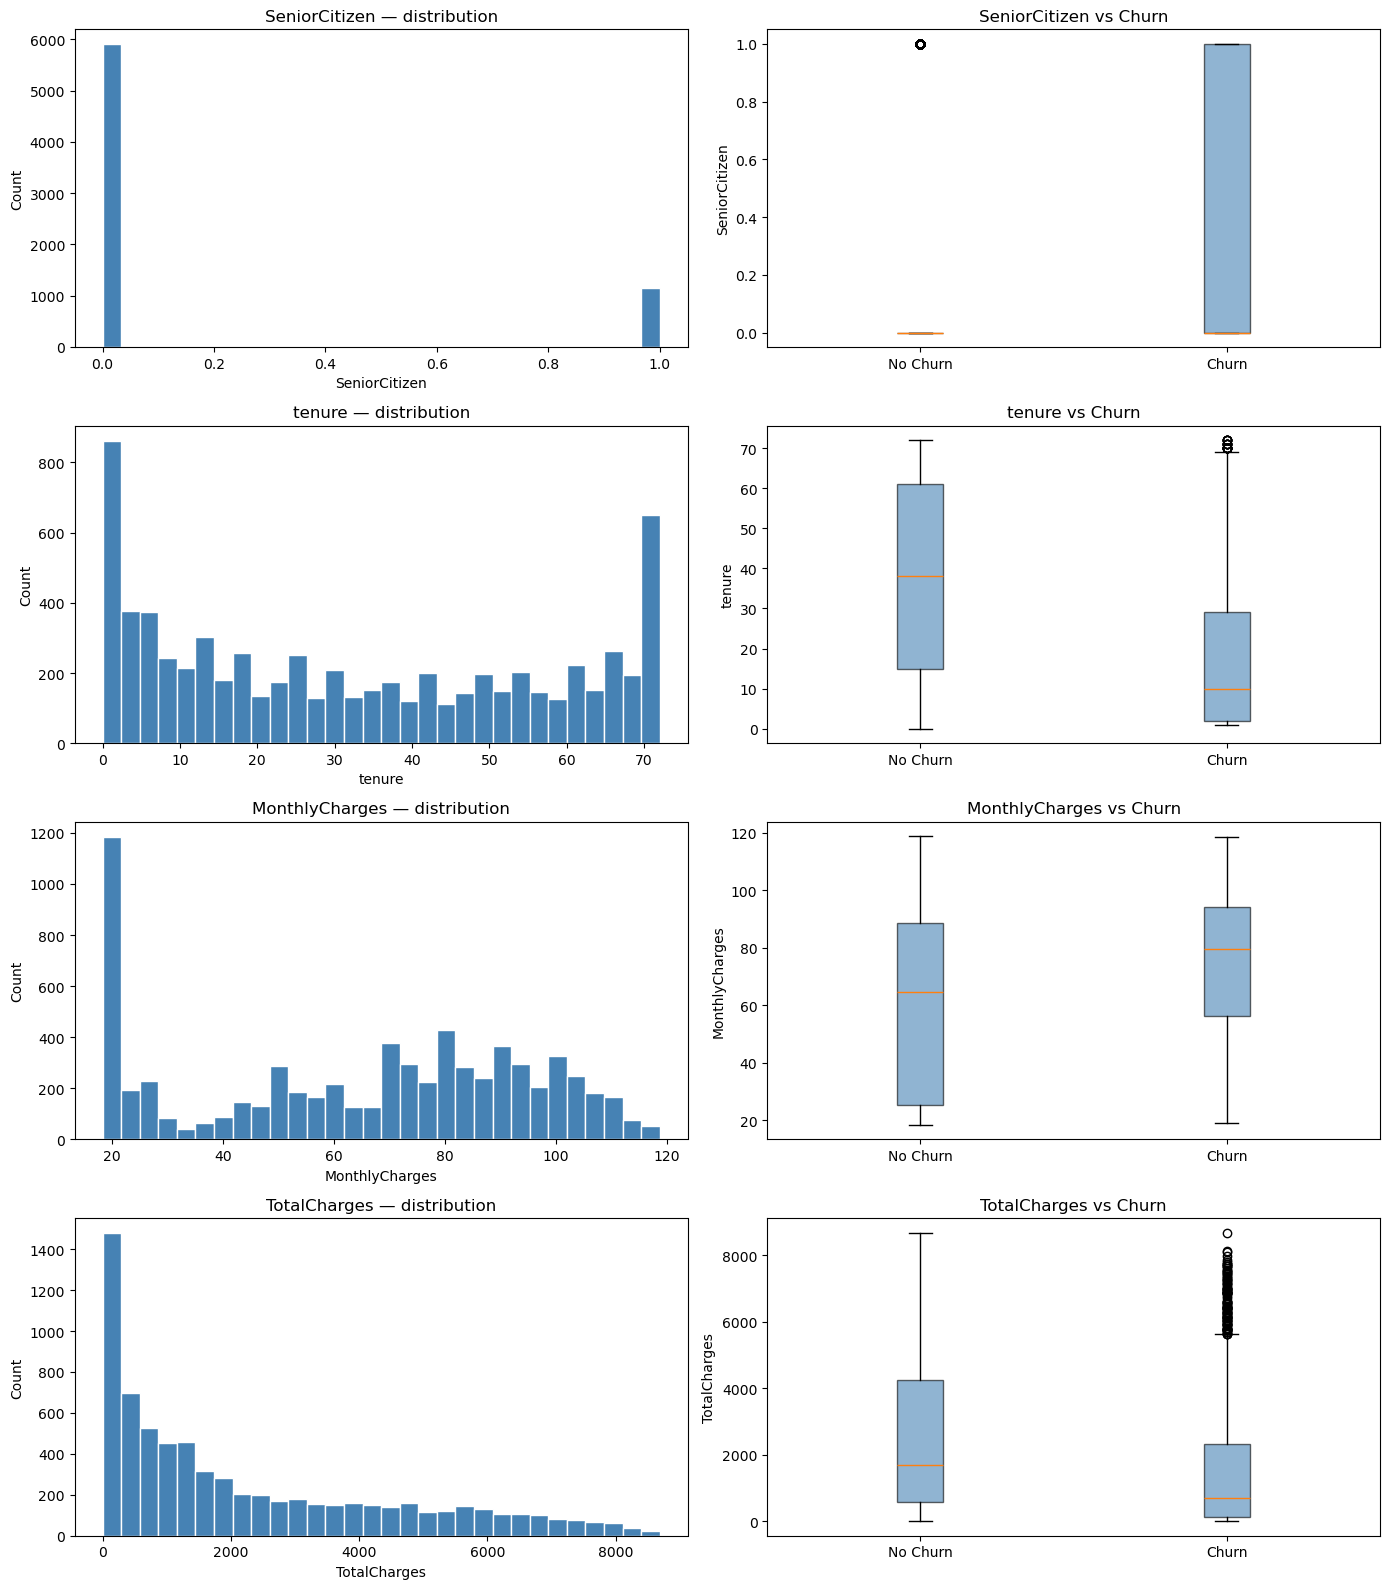

In [11]:
# Distribution + Boxplot vs Churn for each numerical feature
fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(14, 4 * len(numerical_cols)))
axes = np.array(axes).reshape(len(numerical_cols), 2)

for i, col in enumerate(numerical_cols):
    # Left: histogram
    axes[i, 0].hist(teleco_data[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — distribution')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Right: boxplot vs Churn
    no_churn = teleco_data[col][teleco_data['Churn'] == 'No'].dropna()
    yes_churn = teleco_data[col][teleco_data['Churn'] == 'Yes'].dropna()
    axes[i, 1].boxplot([no_churn, yes_churn], labels=['No Churn', 'Churn'],
                       patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i, 1].set_title(f'{col} vs Churn')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [12]:
# Mann-Whitney U test: are the distributions significantly different between churned and non-churned?
print(f'{'Feature':<20} {'p-value':>10}  Significant?')
print('-' * 45)
for col in numerical_cols:
    no_churn = teleco_data[col][teleco_data['Churn'] == 'No'].dropna()
    yes_churn = teleco_data[col][teleco_data['Churn'] == 'Yes'].dropna()
    stat, p = mannwhitneyu(no_churn, yes_churn, alternative='two-sided')
    sig = 'YES' if p < 0.05 else 'no'
    print(f'{col:<20} {p:>10.4f}  {sig}')

Feature                 p-value  Significant?
---------------------------------------------
SeniorCitizen            0.0000  YES
tenure                   0.0000  YES
MonthlyCharges           0.0000  YES
TotalCharges             0.0000  YES


`tenure` is the strongest signal. Churners are concentrated at low values while retained customers spread across the full range. Most churn happens early: customers who stay past a certain point tend to keep staying.

`MonthlyCharges` is higher for churners, probably because Fiber optic customers pay more and also churn more. Price alone may not be the driver but it tracks closely with the service type that does.

`TotalCharges` is lower for churners but this is mostly a tenure effect — customers who left early had less time to accumulate charges. It doesn't add independent signal.

`SeniorCitizen` shows a modest difference between groups but adds little in numeric form. The churn rate split between seniors and non-seniors is more informative and is covered in the categorical section.

### 2.3 Categorical features

Each bar chart shows the churn rate per category within a feature. The navy dashed line is the overall rate (~27%): categories above it churn more than average, below it less.

These charts show which categories within a feature are associated with churn. Whether the overall feature is statistically significant is a separate question, answered by the chi-squared test below.

Chi-squared tests independence between a categorical feature and the target. It compares observed cell counts in a contingency table against what we'd expect if the feature had no relationship with churn:

`χ² = Σ (observed − expected)² / expected`

A large χ² gives a small p-value, meaning the pattern is unlikely to be random. The limitation is that chi-squared only confirms a relationship exists but says nothing about how useful that relationship actually is for prediction. That's what Section 5 is for.

In [13]:
categorical_cols = teleco_data.select_dtypes(include='object').columns.tolist()
categorical_features = [c for c in categorical_cols if c != 'Churn']
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

for col in categorical_features:
    print(f'\n{col}:')
    print(teleco_data[col].value_counts().to_string())

Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

gender:
gender
Male      3555
Female    3488

Partner:
Partner
No     3641
Yes    3402

Dependents:
Dependents
No     4933
Yes    2110

PhoneService:
PhoneService
Yes    6361
No      682

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526

OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526

DeviceProtection:
DeviceProtection
No                     3095
Yes                    2422
No internet service    152

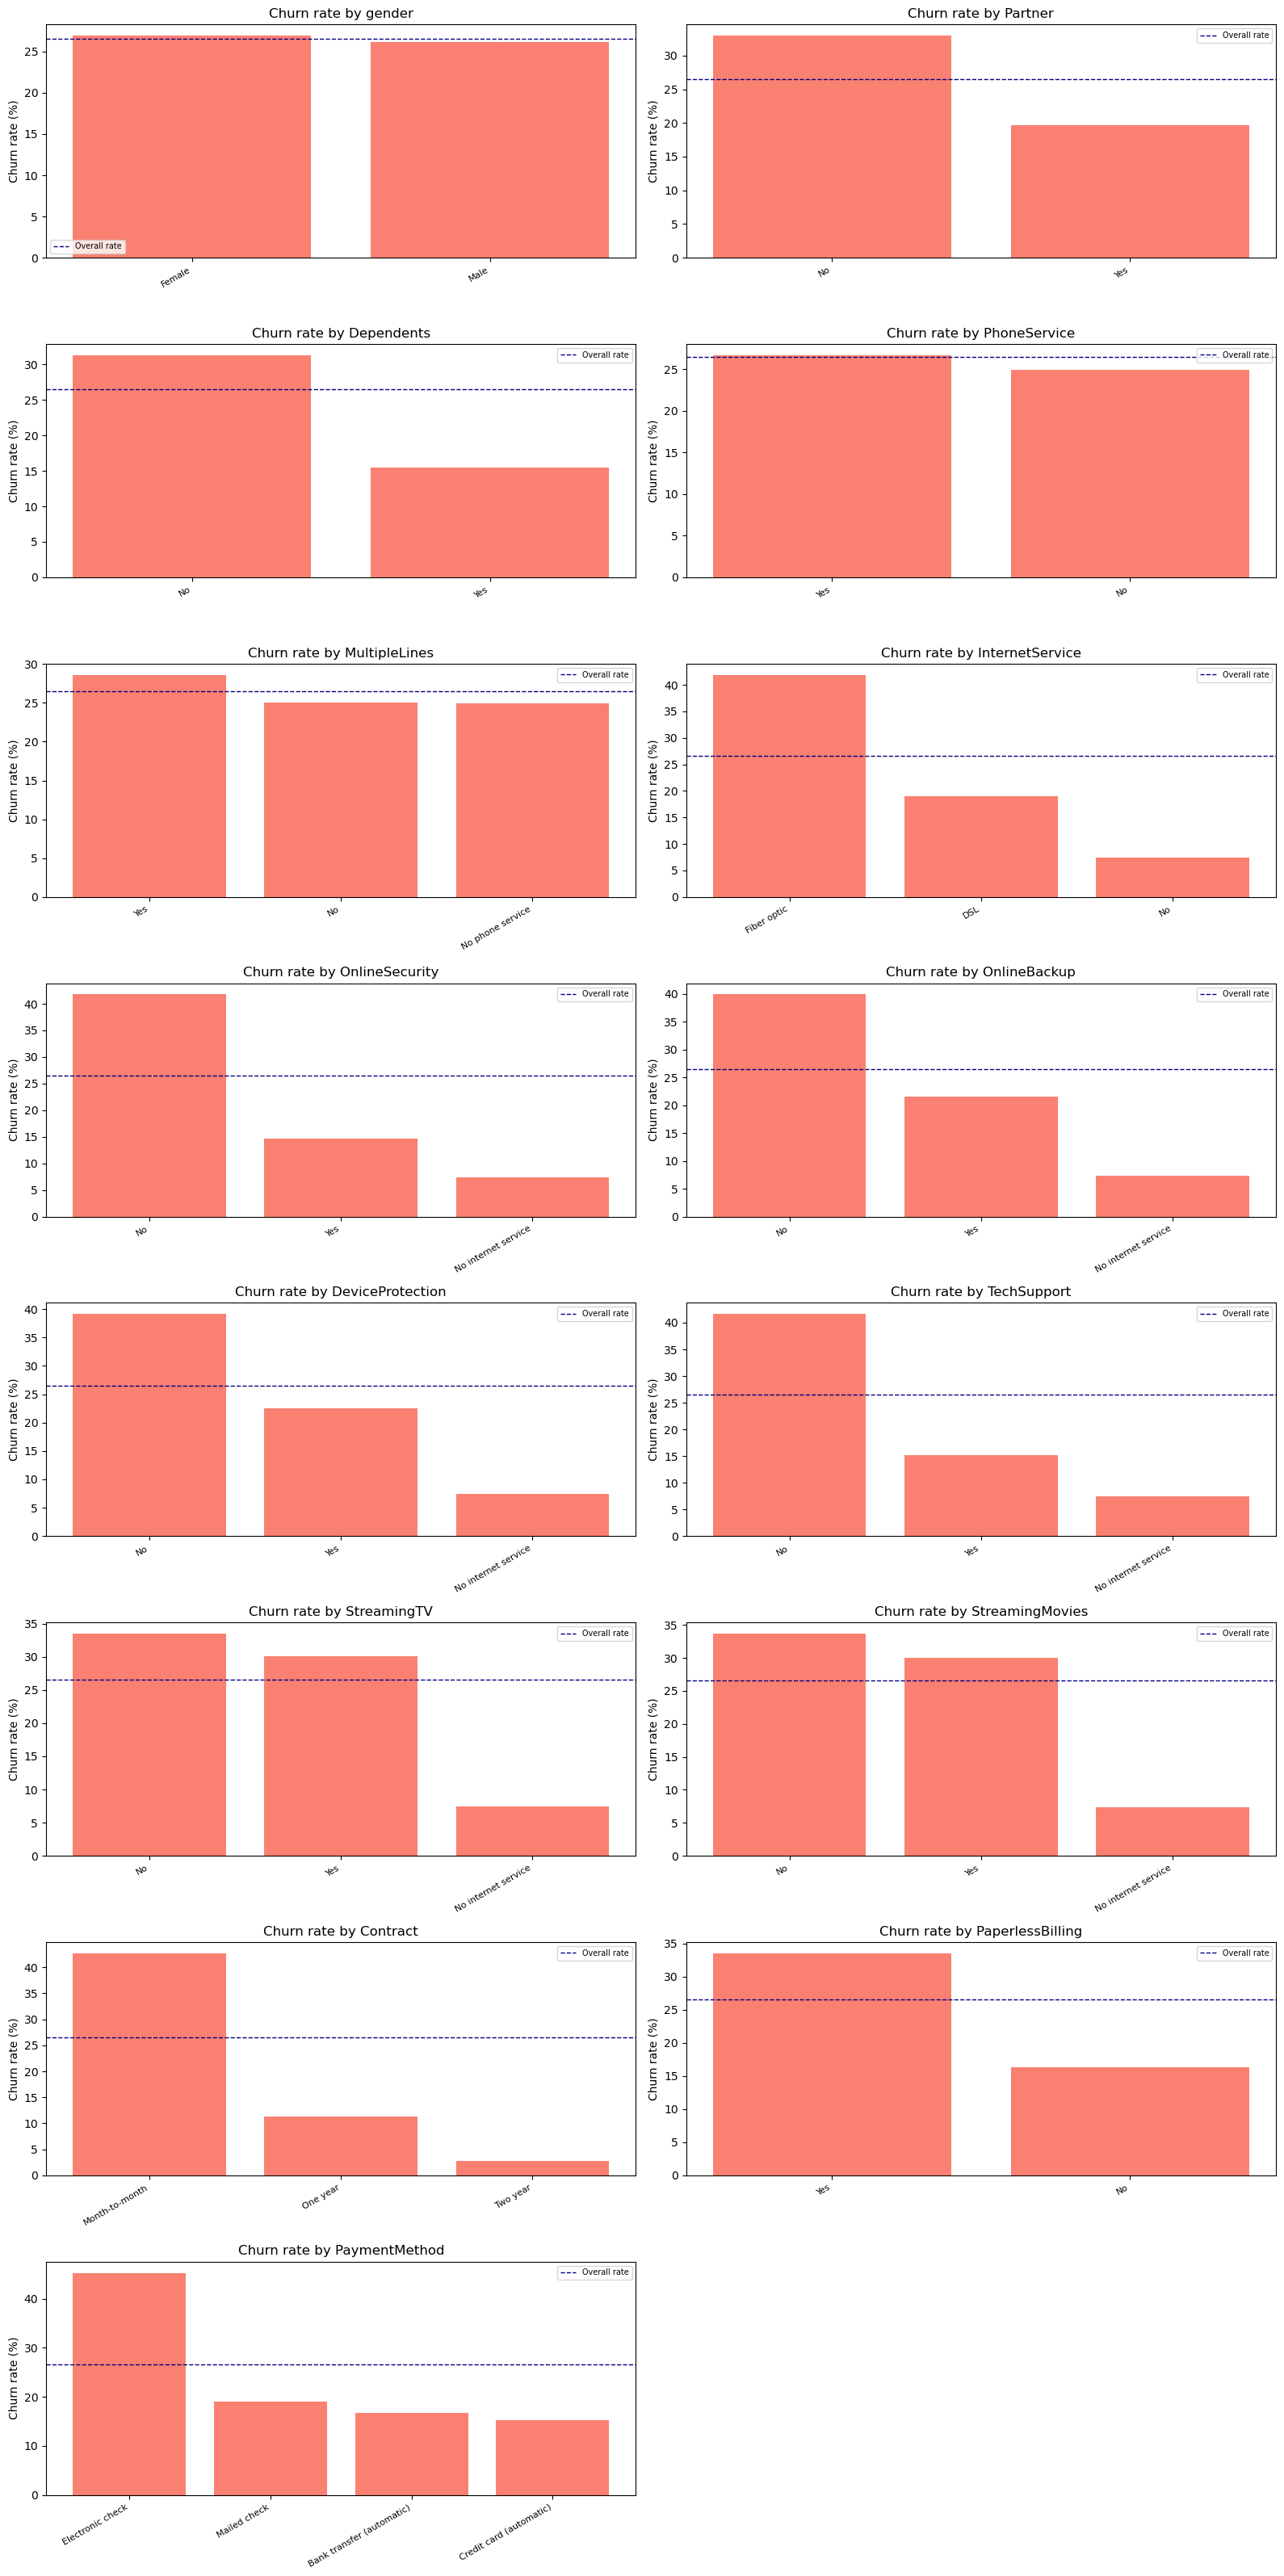

In [14]:
# Churn rate per category for every categorical feature
n = len(categorical_features)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(categorical_features):
    churn_rate = (
        teleco_data.groupby(col)['Churn']
        .apply(lambda x: (x == 'Yes').mean() * 100)
        .sort_values(ascending=False)
    )
    axes[i].bar(range(len(churn_rate)), churn_rate.values, color='salmon')
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right', fontsize=8)
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].axhline(teleco_data['Churn'].eq('Yes').mean() * 100,
                    color='navy', linestyle='--', linewidth=1, label='Overall rate')
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [15]:
# Chi-squared test for all categorical features vs Churn
chi2_results = []
for col in categorical_features:
    c_table = pd.crosstab(teleco_data[col], teleco_data['Churn'])
    chi2, p, dof, _ = chi2_contingency(c_table)
    chi2_results.append({'feature': col, 'chi2': round(chi2, 2), 'p_value': round(p, 6), 'significant': p < 0.05})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
print(chi2_df.to_string(index=False))

         feature    chi2  p_value  significant
         Partner  158.73 0.000000         True
      Dependents  189.13 0.000000         True
  OnlineSecurity  850.00 0.000000         True
 InternetService  732.31 0.000000         True
    OnlineBackup  601.81 0.000000         True
     StreamingTV  374.20 0.000000         True
     TechSupport  828.20 0.000000         True
DeviceProtection  558.42 0.000000         True
        Contract 1184.60 0.000000         True
PaperlessBilling  258.28 0.000000         True
   PaymentMethod  648.14 0.000000         True
 StreamingMovies  375.66 0.000000         True
   MultipleLines   11.33 0.003464         True
    PhoneService    0.92 0.338783        False
          gender    0.48 0.486579        False


`Contract` has the highest chi² by a wide margin. Month-to-month customers churn at much higher rates than those on one- or two-year contracts. Contract type is probably a proxy for commitment: customers on long-term contracts have already made a retention decision.

`OnlineSecurity` and `TechSupport` rank next. Customers without these services churn more, probably because they're on cheaper plans with less friction to leave. `InternetService` and `PaymentMethod` also show strong associations.

`PhoneService` and `gender` are not significant, churn rates are flat across their categories. Drop both.

`MultipleLines` is technically significant but chi-squared only confirms a relationship exists, not how strong it is. The MI scores in Section 5 will settle whether it's worth keeping.

---
## 3. Binary encoding (preprocessing copy)

EDA ran on raw string data. For modelling we need numbers. This section encodes `teleco_preprocessed`, the copy made at the end of cleaning, so `teleco_data` stays untouched throughout the EDA.

Binary columns (Yes/No, Male/Female) get mapped to 0/1. The reference dict below records exactly what maps to what.

In [16]:
def encoding_features(dataset):
    binary_columns = [
        col for col in dataset.select_dtypes(include='object').columns
        if dataset[col].nunique() == 2
    ]
    encoding_reference = {}
    for column in binary_columns:
        unique_values = dataset[column].unique()
        # Map 'Yes' / 'Female' / first positive-sounding value to 1
        pos_val = 'Yes' if 'Yes' in unique_values else unique_values[0]
        dataset[column] = dataset[column].map(lambda x: 1 if x == pos_val else 0)
        encoding_reference[column] = {v: (1 if v == pos_val else 0) for v in unique_values}
    return dataset, encoding_reference

teleco_preprocessed, encodings = encoding_features(teleco_preprocessed)

print('Encoding reference:')
for k, v in encodings.items():
    print(f'  {k}: {v}')

print(f'\nChurn value counts (1 = churned):')
print(teleco_preprocessed['Churn'].value_counts())

Encoding reference:
  gender: {'Female': 1, 'Male': 0}
  Partner: {'Yes': 1, 'No': 0}
  Dependents: {'No': 0, 'Yes': 1}
  PhoneService: {'No': 0, 'Yes': 1}
  PaperlessBilling: {'Yes': 1, 'No': 0}
  Churn: {'No': 0, 'Yes': 1}

Churn value counts (1 = churned):
Churn
0    5174
1    1869
Name: count, dtype: int64


---
## 4. Multicollinearity analysis

Multicollinearity is when features are correlated with each other rather than with the target. For linear models this causes problems: correlated features produce unstable coefficients and the model can't tell which one is actually doing the work. For tree models it's less critical but still worth checking since redundant features waste splits and can skew feature importance scores.

The Spearman correlation heatmap shows pairwise relationships. VIF (Variance Inflation Factor) measures how redundant each feature is by checking how well the other features can predict it:

$$VIF_i = \frac{1}{1 - R_i^2}$$

VIF = 1 means no redundancy, above 10 is a problem. Both analyses use numeric columns only with `Churn` excluded.

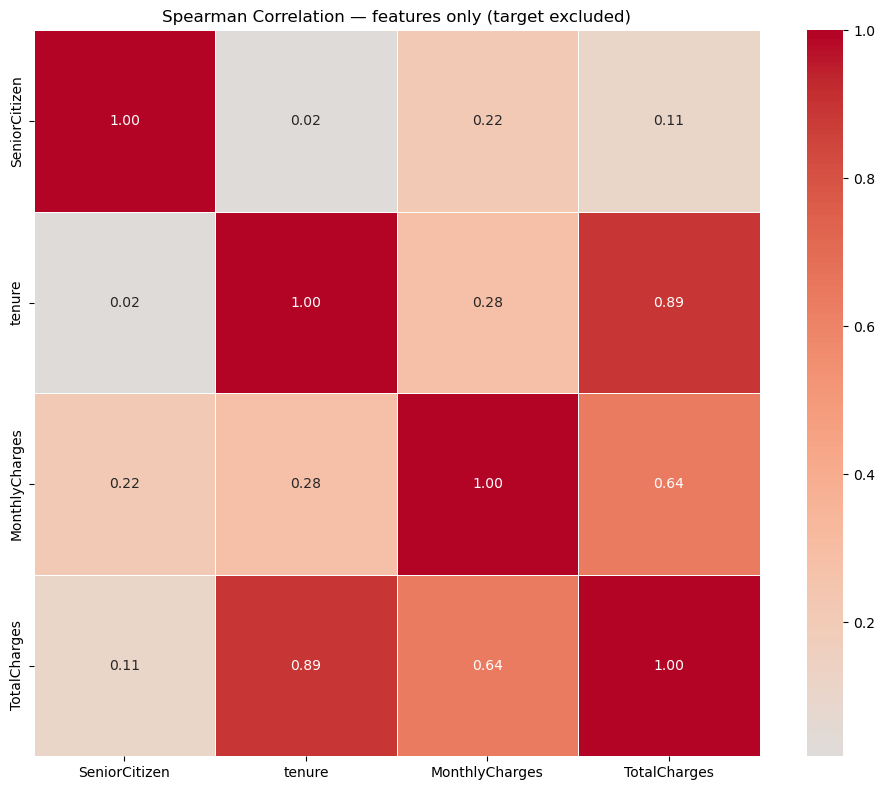

In [17]:
# Spearman correlation heatmap — features only
features_only = teleco_data.drop('Churn', axis=1).select_dtypes(include='number')
corr = features_only.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0,
            linewidths=0.5, square=True)
plt.title('Spearman Correlation — features only (target excluded)')
plt.tight_layout()
plt.show()

In [18]:
# VIF — target excluded
X = teleco_data.drop('Churn', axis=1).select_dtypes(include='number').dropna()
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif.sort_values('VIF', ascending=False).to_string(index=False))

       feature      VIF
  TotalCharges 8.080935
        tenure 6.332627
MonthlyCharges 3.694794
 SeniorCitizen 1.257276


`MonthlyCharges`, `TotalCharges` and `tenure` all exceed VIF 10. That's expected: total charges are roughly monthly rate times months subscribed, so these three are algebraically linked and not independently informative.

To check, `Avg_per_month = TotalCharges / tenure` is compared against `MonthlyCharges`. A near-perfect correlation confirms charges have barely changed over time for most customers. `TotalCharges` adds nothing that `tenure` and `MonthlyCharges` together don't already cover.

In [19]:
# Avg_per_month experiment — avoid divide-by-zero for tenure=0
teleco_data['Avg_per_month'] = teleco_data['TotalCharges'] / teleco_data['tenure'].replace(0, np.nan)

corr_check = teleco_data[['MonthlyCharges', 'Avg_per_month']].corr()
print('Correlation between MonthlyCharges and Avg_per_month:')
print(corr_check)
print('\nConclusion: if correlation ≈ 1 → charges do not vary over time → Avg_per_month adds no new information.')

Correlation between MonthlyCharges and Avg_per_month:
                MonthlyCharges  Avg_per_month
MonthlyCharges        1.000000       0.996237
Avg_per_month         0.996237       1.000000

Conclusion: if correlation ≈ 1 → charges do not vary over time → Avg_per_month adds no new information.


In [20]:
# Drop redundant columns
teleco_data = teleco_data.drop(['Avg_per_month', 'TotalCharges'], axis=1)

# Re-run VIF after dropping
X = teleco_data.drop('Churn', axis=1).select_dtypes(include='number').dropna()
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print('VIF after dropping TotalCharges and Avg_per_month:')
print(vif.sort_values('VIF', ascending=False).to_string(index=False))

VIF after dropping TotalCharges and Avg_per_month:
       feature      VIF
MonthlyCharges 2.924996
        tenure 2.617403
 SeniorCitizen 1.256364


After dropping `TotalCharges`, the remaining numeric features are `tenure`, `MonthlyCharges` and `SeniorCitizen`. VIF is within acceptable range. `MonthlyCharges` is still slightly elevated due to its correlation with `tenure` but not enough to drop — it carries independent signal, particularly for Fiber optic customers.

---
## 5. Mutual information with target

Mutual Information (MI) measures how much knowing a feature reduces uncertainty about the target. Unlike chi-squared, it captures non-linear relationships and works on both numeric and categorical features.

$$MI(X, Y) = \sum_{x,y} P(x,y) \log \frac{P(x,y)}{P(x)P(y)}$$

MI = 0 means the feature and target are independent: useless for prediction. Higher scores mean more shared information.

MI and chi-squared answer different questions. Chi-squared tells you whether a relationship exists, MI tells you how much information that relationship actually provides. A feature can pass chi-squared but score near-zero MI if the relationship is real but too weak to actually improve predictions.

Categorical columns are label-encoded before scoring to get one score per feature, which is cleaner than one-hot that would split each feature into multiple dummy columns. The encoding is only for scoring and doesn't touch the main dataset.

In [21]:
from sklearn.preprocessing import OrdinalEncoder

X_mi = teleco_data.drop('Churn', axis=1)
y_mi = teleco_data['Churn']

# Label-encode categorical columns — one score per feature, cleaner output
X_temp = X_mi.copy()
cat_cols = X_temp.select_dtypes(include='object').columns
X_temp[cat_cols] = OrdinalEncoder().fit_transform(X_temp[cat_cols])

# discrete_features='auto' only checks issparse(X) — on a dense array that
# resolves to False for every column, so encoded categoricals get scored as
# continuous unless told otherwise. Mark them explicitly.
discrete_mask = X_temp.columns.isin(cat_cols)
scores = mutual_info_classif(X_temp, y_mi, discrete_features=discrete_mask, random_state=42)
mi_df = pd.DataFrame({'feature': X_temp.columns, 'mi_score': scores}).sort_values('mi_score', ascending=False)
print(mi_df.to_string(index=False))

         feature  mi_score
        Contract  0.098453
          tenure  0.081688
  OnlineSecurity  0.064677
     TechSupport  0.063021
 InternetService  0.055574
    OnlineBackup  0.046792
  MonthlyCharges  0.045601
   PaymentMethod  0.044519
DeviceProtection  0.043917
 StreamingMovies  0.032001
     StreamingTV  0.031908
PaperlessBilling  0.019194
      Dependents  0.014467
         Partner  0.011454
   SeniorCitizen  0.011413
   MultipleLines  0.000801
    PhoneService  0.000072
          gender  0.000037


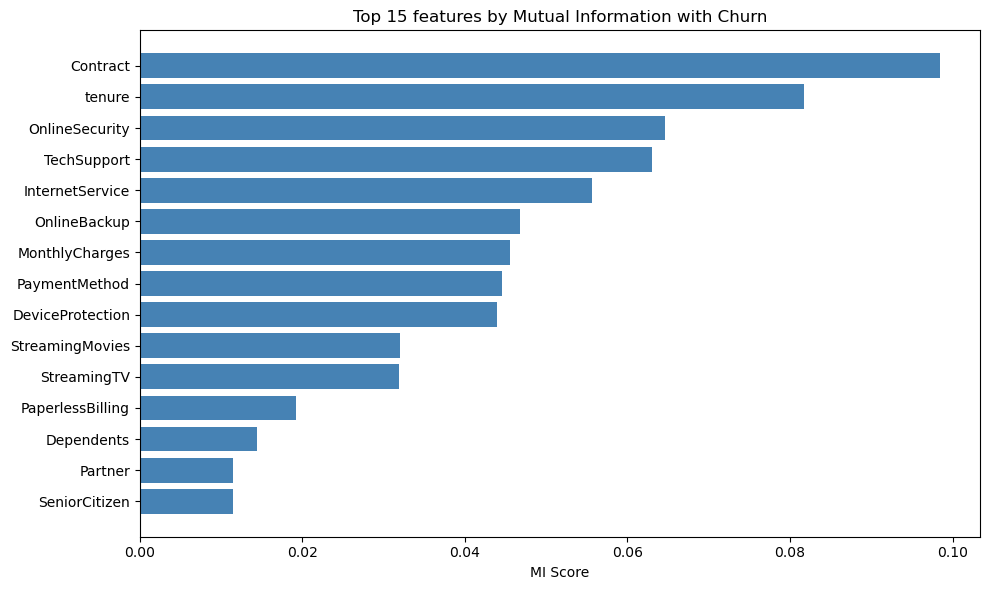

In [22]:
# Top 15 features by MI score
top15 = mi_df.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top15['feature'], top15['mi_score'], color='steelblue')
plt.xlabel('MI Score')
plt.title('Top 15 features by Mutual Information with Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

`Contract` leads, followed by `tenure`. These two carry the most information about churn.

The online services cluster (`OnlineSecurity`, `TechSupport`, `DeviceProtection`, `OnlineBackup`, `StreamingTV`, `StreamingMovies`) all sit in the low-to-mid range. Weak individually, but they all point at the same pattern: customers without add-on services have less invested in the platform and less friction to leave. Keep all of them.

Drop decisions, cross-checked against chi-squared:
- `gender`: MI=0, chi-squared not significant. Drop.
- `PhoneService`: MI near zero, chi-squared not significant. Drop.
- `MultipleLines`: MI=0, chi-squared significant but no predictive value. Drop.
- `SeniorCitizen`: MI near zero, but chi-squared shows a real relationship. Keep and let the model decide.

Drop: `gender`, `PhoneService`, `MultipleLines`.

---
## 6. What we found

| Finding | Implication |
|---|---|
| Class imbalance (~27% churn) | Use F1 and AUC-ROC, not accuracy |
| `TotalCharges` dropped | Algebraically redundant with `tenure × MonthlyCharges` |
| `gender` dropped | MI=0, chi-squared not significant |
| `PhoneService` dropped | MI near zero, chi-squared not significant |
| `MultipleLines` dropped | MI=0, chi-squared significant but no predictive value |
| Online services cluster | Low individual MI but all point at the same pattern. Keep all |
| Top features | `Contract` and `tenure` lead. `PaymentMethod`, `InternetService`, `MonthlyCharges` follow |
| Distributed signal | No single feature dominates. Tree ensembles handle this well |

### Modelling checklist

1. Load `teleco_model_ready.csv` — cleaning and feature drops already applied
2. Encode `Churn` target: Yes → 1, No → 0
3. One-hot encode categoricals in the pipeline: `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod`
4. Stratified train/test split to preserve the 27/73 class ratio
5. Baseline: Logistic Regression
6. Main model: Random Forest or XGBoost
7. Evaluate with F1, AUC-ROC and a confusion matrix

---
## 7. Export for modelling

Clean dataset with confirmed drops applied. No encoding — that goes in the pipeline.

In [23]:
cols_to_drop = ['gender', 'PhoneService', 'MultipleLines']
teleco_model = teleco_data.drop(cols_to_drop, axis=1)
teleco_model.to_csv('teleco_model_ready.csv', index=False)

print(f'Saved → teleco_model_ready.csv')
print(f'Shape: {teleco_model.shape}')
print(f'\nColumns: {teleco_model.columns.tolist()}')
print(f'\nDtypes:\n{teleco_model.dtypes}')

Saved → teleco_model_ready.csv
Shape: (7043, 16)

Columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'Churn']

Dtypes:
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
Churn                object
dtype: object
